<a href="https://colab.research.google.com/github/gencina-star/TFM/blob/main/EDA_Accidentes_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM - Auxiliar para Accidentes de Tráfico (Madrid)

# Instalacion

In [ ]:
!pip install geopandas folium scikit-learn pandas pyarrow -q9

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/TFM/notebooks'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Librerias

In [ ]:
# Librerias
import sys
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
from pathlib import Path
from charset_normalizer import from_path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Funcion Auxiliar: Diccionario para Geolocalizacion

In [ ]:
%%writefile normalizer_madrid.py

import re


# ══════════════════════════════════════════════════════════════════════════════
# NORMALIZADOR DE DIRECCIONES MADRID → Google Maps Geocoding API
# Versión 1.0
# ══════════════════════════════════════════════════════════════════════════════
# Cubre todos los datasets procesados para el TFM de accidentes/multas Madrid.
# Reglas aplicadas en orden:
#   1. Limpieza de prefijos de farola/código interno
#   2. Intersecciones conocidas (hardcoded)
#   3. Tramos de autopista (M-30, M-23, A-5, A-2, etc.)
#   4. Intersecciones dinámicas (guión, ESQ, CON)
#   5. Paseos/Avenidas/Glorietas con número
#   6. Calles con número
#   7. Resolución de nombre único de calle/plaza
# ══════════════════════════════════════════════════════════════════════════════

# Las reglas están aplicadas en este orden de prioridad dentro de normalizar_direccion_madrid:
# 1 — Lookup directo en tabla de 80+ intersecciones y nombres complejos conocidos que no pueden parsearse automáticamente (ej. TRAMO AV CORDOBA GT CADIZ-F64, P. SM.CABEZA_N115).
# 2 — Sinesio Delgado con sufijos de tramo (IMPAR F152-143, PAR F144-152) → colapsa a Calle Sinesio Delgado.
# 3 — M-23 → extrae km si existe, si no devuelve M-23, Madrid, España.
# 4 — M-30 → primero busca intersección con calle conocida (ALCALA M 30, MENDEZ ALVARO M 30…), luego extrae km, si no devuelve genérico.
# 5 — Otras autopistas (A-5, A-2, A-3, A-4, A-42, M-11, M-40…) → maneja rangos KMS 4-5.7 calculando el km central.
# 6 — Prefijo de farola/código (F029, N073, SN, TPZC…) → se elimina antes de continuar.
# 7 — Intersecciones dinámicas (separadores -, ESQ, CON) → construye X con Y.
# 8/9 — Número al final y resolución de vía por lookup en diccionario de ~150 abreviaturas (PO, AV, GV, PZ, GTA, CR…).
# Si encuentras casos nuevos que no normaliza bien, puedes añadirlos al diccionario _KNOWN_INTERSECTIONS (para casos fijos) o a _STREET_MAP (para abreviaturas de vía).

# ─────────────────────────────────────────────────────────────────────────────
# REGEX: prefijos de farola/código a eliminar al inicio del string
# ─────────────────────────────────────────────────────────────────────────────
_RE_PREFIX = re.compile(
    r'^(?:'
    r'[FKN][0-9A-Z]{1,5}[A-Z0-9]?'      # F029, K091, N098, F29V, F60M...
    r'|[0-9]{2,3}'                         # 052, 113, 130
    r'|(?:SN|S/N|S\sN|FSÑN?|NSÑN?|NSNM?'
    r'|SÑN|NS_N|NS/N|SN[0-9]+|NO[0-9]+'
    r'|PK[0-9]+|FR[0-9]+|MADR|FUER|AVDF'
    r'|PEDR|TPZC|SUBT)'
    r'|F\s+[0-9]+'                         # F 126
    r')\s+',
    re.IGNORECASE
)

# ─────────────────────────────────────────────────────────────────────────────
# INTERSECCIONES CONOCIDAS (lookup directo antes de cualquier parsing)
# ─────────────────────────────────────────────────────────────────────────────
_KNOWN_INTERSECTIONS = {
    "ALCALA - SAN ROMUALDO":              "Calle Alcalá con Calle San Romualdo, Madrid, España",
    "VIA LUSITANA - PL ELIPTICA":         "Vía Lusitana con Plaza de la Elíptica, Madrid, España",
    "116 VIA LUSITANA - PL ELIPTICA":     "Vía Lusitana con Plaza de la Elíptica, Madrid, España",
    "TRAMO AV CORDOBA GT CADIZ-F64":      "Avenida de Córdoba con Glorieta de Cádiz, Madrid, España",
    "CEA BERMUDEZ - VALLEHERMOSO":        "Calle Cea Bermúdez con Calle Vallehermoso, Madrid, España",
    "124 CEA BERMUDEZ - VALLEHERMOS":     "Calle Cea Bermúdez con Calle Vallehermoso, Madrid, España",
    "GRAL RICARDOS - QUINCE MAYO":        "Calle General Ricardos con Calle Quince de Mayo, Madrid, España",
    "123 GNRAL RICARDOS - PSO QUINC":     "Calle General Ricardos con Calle Quince de Mayo, Madrid, España",
    "O'DONNELL CON DOCTOR ESQUERDO":      "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España",
    "097 ODONNELL CON DOCTOR ESQUER":     "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España",
    "JOSE ABASCAL - SANTA ENGRACIA":      "Calle José Abascal con Calle Santa Engracia, Madrid, España",
    "117 JOSE ABASCAL - SANTA ENGRA":     "Calle José Abascal con Calle Santa Engracia, Madrid, España",
    "ALBERTO AGUILERA - B. GRACIAN":      "Calle Alberto Aguilera con Calle Baltasar Gracián, Madrid, España",
    "114 ALBERTO AGUILERA - BALTASA":     "Calle Alberto Aguilera con Calle Baltasar Gracián, Madrid, España",
    "AV AMERICA - CARTAGENA":             "Avenida de América con Calle Cartagena, Madrid, España",
    "119 AV. AMERICA - CARTAGENA":        "Avenida de América con Calle Cartagena, Madrid, España",
    "CARAB. ARAVACA - VILLAVICIOSA":      "Carretera de Carabanchel a Aravaca con Calle Villaviciosa, Madrid, España",
    "121 CRA. CARABANCHEL ARAVACA -":     "Carretera de Carabanchel a Aravaca, Madrid, España",
    "JOAQUIN COSTA - VELAZQUEZ":          "Calle Joaquín Costa con Calle Velázquez, Madrid, España",
    "M. CORBERA - RICARDO ORTIZ":         "Avenida del Marqués de Corbera con Calle Ricardo Ortiz, Madrid, España",
    "110 AV MARQUES DE CORBERA - RI":     "Avenida del Marqués de Corbera con Calle Ricardo Ortiz, Madrid, España",
    "AV ANDALUCIA ESQ ALCOCER":           "Avenida de Andalucía con Calle Alcocer, Madrid, España",
    "106 AV ANDALUCIA ESQ ALCOCER":       "Avenida de Andalucía con Calle Alcocer, Madrid, España",
    "AV ILUSTRACION ESQ BETANZOS":        "Avenida de la Ilustración con Avenida de Betanzos, Madrid, España",
    "090 AV ILUSTRACION ESQ BETANZO":     "Avenida de la Ilustración con Avenida de Betanzos, Madrid, España",
    "MONFORTE LEMOS - FINISTERRE":        "Avenida de Monforte de Lemos con Calle Finisterre, Madrid, España",
    "118 MONFORTE DE LEMOS - FINIST":     "Avenida de Monforte de Lemos con Calle Finisterre, Madrid, España",
    "C. BARRIAL - FDO. L. CARRETER":      "Camino del Barrial con Calle Fernando Lázaro Carreter, Madrid, España",
    "120 CMNO BARRIAL - FDO LAZARO":      "Camino del Barrial con Calle Fernando Lázaro Carreter, Madrid, España",
    "MENENDEZ PELAYO H. NIÑO JESUS":      "Avenida de Menéndez Pelayo con Hospital del Niño Jesús, Madrid, España",
    "099 MENENDEZ PELAYO H. NIÑO JE":     "Avenida de Menéndez Pelayo con Hospital del Niño Jesús, Madrid, España",
    "AV PESETA - CTRA B. FORTUNA":        "Avenida de la Peseta con Carretera del Barrio de la Fortuna, Madrid, España",
    "122 AV. PESETA - CTRA BARRIO F":     "Avenida de la Peseta con Carretera del Barrio de la Fortuna, Madrid, España",
    "AV ANDALUCIA METRO S.CRISTOBAL":     "Avenida de Andalucía, San Cristóbal de los Ángeles, Madrid, España",
    "091 AV ANDALUCIA METRO S.CRIST":     "Avenida de Andalucía, San Cristóbal de los Ángeles, Madrid, España",
    "CIUDAD BARCELONA - M. PELAYO":       "Avenida de la Ciudad de Barcelona con Avenida de Menéndez Pelayo, Madrid, España",
    "SINESIO DELGADO GTA P. CEBRERO":     "Calle Sinesio Delgado con Glorieta de Pío Cebrero, Madrid, España",
    "101 SINESIO DELGADO GTA P. CEB":     "Calle Sinesio Delgado con Glorieta de Pío Cebrero, Madrid, España",
    "FTE CARRANTONA ESQ HAC.PAVONES":     "Calle Fuente Carrantona con Calle Hacienda de Pavones, Madrid, España",
    "105 FTE CARRANTONA ESQ HAC.PAV":     "Calle Fuente Carrantona con Calle Hacienda de Pavones, Madrid, España",
    "AV POBLADOS-EST. ALUCHE F 56":       "Avenida de los Poblados con Estación de Aluche, Madrid, España",
    "085 AV POBLADOS-EST. ALUCHE F":      "Avenida de los Poblados con Estación de Aluche, Madrid, España",
    "AV LOGROÑO ESQ JOAQUIN IBARRA":      "Avenida de Logroño con Calle Joaquín Ibarra, Madrid, España",
    "089 AV LOGROÑO ESQ JOAQUIN IBA":     "Avenida de Logroño con Calle Joaquín Ibarra, Madrid, España",
    "ASCAO - EMILIO FERRARI":             "Calle Áscao con Calle Emilio Ferrari, Madrid, España",
    "112 ASCAO - EMILIO FERRARI":         "Calle Áscao con Calle Emilio Ferrari, Madrid, España",
    "FCO PI Y MARGALL ESQ ANA AUST":      "Calle Francisco Pi y Margall con Calle Ana de Austria, Madrid, España",
    "104 FCO PI Y MARGALL ESQ ANA A":     "Calle Francisco Pi y Margall con Calle Ana de Austria, Madrid, España",
    "AV C. HERRERA ORIA ESQ LA MASO":     "Avenida del Cardenal Herrera Oria con Calle La Masona, Madrid, España",
    "SUBTRRANEO COSTA RICA":              "Calle Costa Rica, Madrid, España",
    "JOAQUIN COSTA, 36":                  "Calle Joaquín Costa 36, Madrid, España",
    "FRANCISCO SILVELA, 99":              "Calle Francisco Silvela 99, Madrid, España",
    "JOSE ABASCAL 58":                    "Calle José Abascal 58, Madrid, España",
    "JOSE ABASCAL, 58":                   "Calle José Abascal 58, Madrid, España",
    "TUCAN TUCAN":                        "Calle Tucán, Madrid, España",
    "HERMANOS GARCIA NOBLEJAS":           "Calle Hermanos García Noblejas, Madrid, España",
    "HNOS. GARCÍA NOBLEJAS 123":          "Calle Hermanos García Noblejas 123, Madrid, España",
    "HERMANOS GARCIA NOBLEJAS 123":       "Calle Hermanos García Noblejas 123, Madrid, España",
    "FRANCISCO LARGO CABALLERO":          "Calle Francisco Largo Caballero, Madrid, España",
    "FRANCISCO VILLAESPESA":              "Calle Francisco Villaespesa, Madrid, España",
    "RAIMUNDO FERNANDEZ VILLAVERDE":      "Calle Raimundo Fernández Villaverde, Madrid, España",
    "PRINCIPE DE VERGARA":                "Calle Príncipe de Vergara, Madrid, España",
    "MAURICIO LEGENDRE":                  "Calle Mauricio Legendre, Madrid, España",
    "JOSE ORTEGA Y GASSET":               "Calle José Ortega y Gasset, Madrid, España",
    "ENCOMIENDA DE PALACIOS":             "Calle Encomienda de Palacios, Madrid, España",
    "MONASTERIOS DE SUSO Y YUSO":         "Calle Monasterios de Suso y Yuso, Madrid, España",
    "DOCTOR TOLOSA LATOUR":               "Calle Doctor Tolosa Latour, Madrid, España",
    "AV MONFORTE DE LEMOS":               "Avenida de Monforte de Lemos, Madrid, España",
    "AV PABLO IGLESIAS":                  "Avenida de Pablo Iglesias, Madrid, España",
    "AV REINA VICTORIA":                  "Avenida de la Reina Victoria, Madrid, España",
    "AV GRAN VIA DE VILLAVERDE":          "Gran Vía de Villaverde, Madrid, España",
    "AV GRAN VIA DE SAN FRANCISCO":       "Gran Vía de San Francisco, Madrid, España",
    "AV INSTITUCION LIBRE ENSEÑANZA":     "Avenida de la Institución Libre de Enseñanza, Madrid, España",
    "081 INSTITUCIÓN LIBRE DE ENSEÑ":     "Avenida de la Institución Libre de Enseñanza, Madrid, España",
    "INSTITUCION LIBRE ENSEÑANZA123":     "Avenida de la Institución Libre de Enseñanza 123, Madrid, España",
    "AV VENTISQUERO CONDESA 42":          "Avenida del Ventisquero de la Condesa 42, Madrid, España",
    "088 AV VENTISQUERO CONDESA 42":      "Avenida del Ventisquero de la Condesa 42, Madrid, España",
    "AV FRANCISCO PI Y MARGALL":          "Avenida de Francisco Pi y Margall, Madrid, España",
    "AV INGENIERO EMILIO HERRERA":        "Avenida del Ingeniero Emilio Herrera, Madrid, España",
    "AV JUAN DE HERRERA":                 "Avenida Juan de Herrera, Madrid, España",
    "AV ALBERTO ALCOCER":                 "Avenida de Alberto Alcocer, Madrid, España",
    "AV ENSANCHE DE VALLECAS":            "Avenida del Ensanche de Vallecas, Madrid, España",
    "AV LLANO CASTELLANO":                "Avenida Llano Castellano, Madrid, España",
    "AV DOCTOR GARCIA TAPIA":             "Avenida del Doctor García Tapia, Madrid, España",
    "AV NICETO ALCALA ZAMORA":            "Avenida de Niceto Alcalá-Zamora, Madrid, España",
    "AV CANILLEJAS A VICALVARO":          "Avenida de Canillejas a Vicálvaro, Madrid, España",
    "PO SANTA MARIA DE LA CABEZA":        "Paseo de Santa María de la Cabeza, Madrid, España",
    "PO SAN FRANCISCO DE SALES":          "Paseo de San Francisco de Sales, Madrid, España",
    "PO MARCELINO CAMACHO":               "Paseo de Marcelino Camacho, Madrid, España",
    "GTA PUERTA DE TOLEDO-TOLEDO":        "Glorieta de la Puerta de Toledo con Calle Toledo, Madrid, España",
    "NUESTRA SEÑORA DE VALVERDE":         "Calle Nuestra Señora de Valverde, Madrid, España",
    "FRAY BERNARDINO SAHAGUN":            "Calle Fray Bernardino de Sahagún, Madrid, España",
    "AV CARDENAL HERRERA ORIA":           "Avenida del Cardenal Herrera Oria, Madrid, España",
    "P. SM.CABEZA_N115":                  "Paseo de Santa María de la Cabeza 115, Madrid, España",
    "P. CASTELLANA_300":                  "Paseo de la Castellana 300, Madrid, España",
    "AV ANDALUCIA 73":                    "Avenida de Andalucía 73, Madrid, España",
}

# ─────────────────────────────────────────────────────────────────────────────
# DICCIONARIO DE VÍAS (prefijo abreviado → nombre completo expandido)
# Se aplica al string una vez eliminado el prefijo de farola
# ─────────────────────────────────────────────────────────────────────────────
_STREET_MAP = {
    # Paseos
    "PO CASTELLANA":           "Paseo de la Castellana",
    "PO EXTREMADURA":          "Paseo de Extremadura",
    "PO ERMITA DEL SANTO":     "Paseo de la Ermita del Santo",
    "PO SANTA MARIA CABEZ":    "Paseo de Santa María de la Cabeza",
    "PO YESERIAS":             "Paseo de las Yeserías",
    "PO REINA CRISTINA":       "Paseo de la Reina Cristina",
    "PO HABANA":               "Paseo de La Habana",
    "PO VIRGEN DEL PUERTO":    "Paseo de la Virgen del Puerto",
    "PO MORET":                "Paseo de Moret",
    "PO CAMOENS Y VALERO":     "Paseo de Camoens y Valero",
    "PO CEREZOS":              "Paseo de los Cerezos",
    "PO PRADO":                "Paseo del Prado",
    "PO DELICIAS":             "Paseo de las Delicias",
    "PO INFANTA ISABEL":       "Paseo de la Infanta Isabel",
    "PO RECOLETOS":            "Paseo de Recoletos",
    "PO CHOPERA":              "Paseo de la Chopera",
    "PO PONTONES":             "Paseo de los Pontones",
    "PO URUGUAY":              "Paseo de Uruguay",
    "PO FERROVIARIOS":         "Paseo de los Ferroviarios",
    "PO PUERTA ANGEL":         "Paseo de la Puerta del Ángel",
    "PO GENERAL MARTINEZ":     "Paseo del General Martínez Campos",
    "PO TALLERES":             "Paseo de los Talleres",
    "PO DIRECCION":            "Paseo de la Dirección",
    "PO IMPERIAL":             "Paseo Imperial",
    # Carreteras
    "CR CASTILLA":             "Carretera de Castilla",
    "CR CARABANCHEL VILLA":    "Carretera de Carabanchel a Aravaca",
    "CR VILLAVERDE VALLEC":    "Carretera de Villaverde a Vallecas",
    "CR FUENCARRAL ALCOBE":    "Carretera de Fuencarral a Alcobendas",
    "CR ACCESO ESTACION A":    "Carretera de Acceso a la Estación de Atocha",
    "CR BOADILLA MONTE":       "Carretera de Boadilla del Monte",
    "CTRA ESTACION DE HORTALEZA": "Carretera de la Estación de Hortaleza",
    "CTRA VILLAVERDE A VALLECAS": "Carretera de Villaverde a Vallecas",
    "CTRA VICALVARO A VALLECAS":  "Carretera de Vicálvaro a Vallecas",
    # Gran Vía de / Rondas / Cuestas / Bulevares
    "GV VILLAVERDE":           "Gran Vía de Villaverde",
    "GV HORTALEZA":            "Avenida Gran Vía de Hortaleza",
    "RDA SEGOVIA":             "Ronda de Segovia",
    "RDA TOLEDO":              "Ronda de Toledo",
    "RD SEGOVIA":              "Ronda de Segovia",
    "RD TOLEDO":               "Ronda de Toledo",
    "CU SAN VICENTE":          "Cuesta de San Vicente",
    "CU SAGRADO CORAZON":      "Cuesta del Sagrado Corazón",
    "BU JOSE PRAT":            "Bulevar de José Prat",
    # Avenidas
    "AV ANDALUCIA":            "Avenida de Andalucía",
    "AV ENTREVIAS":            "Avenida de Entrevías",
    "AV RAMON Y CAJAL":        "Avenida de Ramón y Cajal",
    "AV AMERICA":              "Avenida de América",
    "AV MEDITERRANEO":         "Avenida del Mediterráneo",
    "AV MACHUPICHU":           "Avenida de Machupichu",
    "AV ANDES":                "Avenida de los Andes",
    "AV CARDENAL HERRERA":     "Avenida del Cardenal Herrera Oria",
    "AV C. HERRERA ORIA":      "Avenida del Cardenal Herrera Oria",
    "AV LOGROÑO":              "Avenida de Logroño",
    "AV DEMOCRACIA":           "Avenida de la Democracia",
    "AV MAYORAZGO":            "Avenida del Mayorazgo",
    "AV ARCENTALES":           "Avenida de Arcentales",
    "AV TRECE ROSAS":          "Avenida de las Trece Rosas",
    "AV VALLADOLID":           "Avenida de Valladolid",
    "AV REAL DE PINTO":        "Avenida Real de Pinto",
    "AV CIUDAD BARCELONA":     "Avenida de la Ciudad de Barcelona",
    "AV CIUDAD DE BARCELONA":  "Avenida de la Ciudad de Barcelona",
    "AV C BARCELONA":          "Avenida de la Ciudad de Barcelona",
    "AV PABLO IGLESIAS":       "Avenida de Pablo Iglesias",
    "AV PABLO NERUDA":         "Avenida Pablo Neruda",
    "AV VICTORIA":             "Avenida de la Victoria",
    "AV PUERTA DE HIERRO":     "Avenida de la Puerta de Hierro",
    "AV PADRE HUIDOBRO":       "Avenida del Padre Huidobro",
    "AV VEINTICINCO SEPTI":    "Avenida de Veinticinco de Septiembre",
    "AV NICETO ALCALA ZAM":    "Avenida de Niceto Alcalá-Zamora",
    "AV POBLADOS":             "Avenida de los Poblados",
    "AV MONASTERIO SILOS":     "Avenida del Monasterio de Silos",
    "AV VALDEMARIN":           "Avenida de Valdemarín",
    "AV REYES CATOLICOS":      "Avenida de los Reyes Católicos",
    "AV ARAGON":               "Avenida de Aragón",
    "AV DAROCA":               "Avenida de Daroca",
    "AV FUERZAS ARMADAS":      "Avenida de las Fuerzas Armadas",
    "AV PESETA":               "Avenida de la Peseta",
    "AV ILUSTRACION":          "Avenida de la Ilustración",
    "AV AURORA BOREAL":        "Avenida Aurora Boreal",
    "AV ASTER":                "Avenida del Aster",
    "AV MADROÑOS":             "Avenida de los Madroños",
    "AV OPORTO":               "Avenida de Oporto",
    "AV FILIPINAS":            "Avenida de Filipinas",
    "AV BURGOS":               "Avenida de Burgos",
    "AV PIO XII":              "Avenida de Pío XII",
    "AV RAFAELA YBARRA":       "Avenida Rafaela Ybarra",
    "AV BUENOS AIRES":         "Avenida de Buenos Aires",
    "AV CONCHA ESPINA":        "Avenida de Concha Espina",
    "AV MONFORTE DE LEMOS":    "Avenida de Monforte de Lemos",
    "AV MONFORTE LEMOS":       "Avenida de Monforte de Lemos",
    "AV ENSANCHE VALLECAS":    "Avenida del Ensanche de Vallecas",
    "AV FCO J SAENZ OIZA":     "Avenida Francisco Javier Sáenz de Oiza",
    "AV JUAN A SAMARANCH":     "Avenida Juan Antonio Samaranch",
    "AV JUAN DE HERRERA":      "Avenida Juan de Herrera",
    "AV CAMILO JOSE CELA":     "Avenida Camilo José Cela",
    "AV PLANETARIO":           "Avenida del Planetario",
    "AV PORTUGAL":             "Avenida de Portugal",
    "AV PARTENON":             "Avenida del Partenón",
    "AV ALBERTO ALCOCER":      "Avenida de Alberto Alcocer",
    "AV COMANDANTE FRANCO":    "Avenida del Comandante Franco",
    "AV SANTO ANGEL GUARD":    "Avenida del Santo Ángel de la Guarda",
    "AV SANTO DOMINGO CAL":    "Avenida de Santo Domingo de la Calzada",
    "AV VEINTICINCO DE SEPTIEMBRE": "Avenida de Veinticinco de Septiembre",
    "AV BRASILIA":             "Avenida de Brasilia",
    "AV BONN":                 "Avenida de Bonn",
    "AV NIZA":                 "Avenida de Niza",
    "AV LLANO CASTELLANO":     "Avenida Llano Castellano",
    "AV PADRE HUIDOBRO":       "Avenida del Padre Huidobro",
    "AV MARQUES CORBERA":      "Avenida del Marqués de Corbera",
    "AV MARQUES DE CORBERA":   "Avenida del Marqués de Corbera",
    "AV SUR AEROP.BARAJAS":    "Avenida Sur del Aeropuerto de Barajas",
    "AV.SUR AEROP.BARAJAS":    "Avenida Sur del Aeropuerto de Barajas",
    "AV ALEJANDRO SOTA":       "Avenida Alejandro de la Sota",
    "AV SENECA":               "Avenida de Séneca",
    "AV CORDOBA":              "Avenida de Córdoba",
    "AV ASTURIAS":             "Avenida de Asturias",
    "AV MONASTERIO ESCORI":    "Avenida del Monasterio de El Escorial",
    "AV PALACIO":              "Avenida del Palacio",
    "AV LAS AGUILAS":          "Avenida Las Águilas",
    "AV AGUILAS":              "Avenida Las Águilas",
    "AV RAFAEL ALBERTI":       "Avenida Rafael Alberti",
    "AV ENSANCHE VALLECAS":    "Avenida del Ensanche de Vallecas",
    "AV GAVIA":                "Avenida de La Gavia",
    "AV EURO":                 "Avenida Euro",
    "AV JOSE PRAT":            "Bulevar de José Prat",
    "AV VENTISQUERO DE LA CONDESA": "Avenida del Ventisquero de la Condesa",
    # Glorietas
    "GTA PUERTA DE TOLEDO":    "Glorieta de la Puerta de Toledo",
    "GTA SANTA MARIA DE LA CABEZA": "Glorieta de Santa María de la Cabeza",
    "GTA CUATRO CAMINOS":      "Glorieta de Cuatro Caminos",
    "GTA EMBAJADORES":         "Glorieta de Embajadores",
    "GTA EMILIO CASTELAR":     "Glorieta de Emilio Castelar",
    "GTA MARQUES DE VADILLO":  "Glorieta del Marqués de Vadillo",
    "GTA MAR DE CRISTAL":      "Glorieta del Mar de Cristal",
    "GTA PIRAMIDES":           "Glorieta de las Pirámides",
    "GTA CADIZ":               "Glorieta de Cádiz",
    "GTA BILBAO":              "Glorieta de Bilbao",
    "GTA SAN VICENTE":         "Glorieta de San Vicente",
    "GTA REALES ACADEMIAS":    "Glorieta de las Reales Academias",
    "GTA ISAAC RABIN":         "Glorieta Isaac Rabin",
    "GT PTA TOLEDO":           "Glorieta de la Puerta de Toledo",
    "GT PIRAMIDES":            "Glorieta de las Pirámides",
    "GT BILBAO":               "Glorieta de Bilbao",
    "GT SAN VICENTE":          "Glorieta de San Vicente",
    # Plazas
    "PZ CIBELES":              "Plaza de Cibeles",
    "PZ ESPAÑA":               "Plaza de España",
    "PZ COLON":                "Plaza de Colón",
    "PZ CASTILLA":             "Plaza de Castilla",
    "PZ LEGAZPI":              "Plaza de Legazpi",
    "PZ ELIPTICA":             "Plaza de la Elíptica",
    "PZ EMPERADOR CARLOS V":   "Plaza del Emperador Carlos V",
    "PZ EM.CARLOS V":          "Plaza del Emperador Carlos V",
    "PZ MARIANO DE CAVIA":     "Plaza de Mariano de Cavia",
    "PZ SAGRADOS CORAZONES":   "Plaza de los Sagrados Corazones",
    "PZ GRECIA":               "Plaza de Grecia",
    "PZ LIMA":                 "Plaza de Lima",
    "PZ REPUBLICA DOMINICANA": "Plaza de la República Dominicana",
    "PZ REPUBLICA DE CHILE":   "Plaza de la República de Chile",
    "PZ INDEPENDENCIA":        "Plaza de la Independencia",
    "PZ MANUEL BECERRA":       "Plaza de Manuel Becerra",
    "PZ JOSE MARIA SOLER":     "Plaza José María Soler",
    "PZ J.MA. SOLER":          "Plaza José María Soler",
    "PZ CONDE CASAL":          "Plaza del Conde de Casal",
    "PZ CONDE DE CASAL":       "Plaza del Conde de Casal",
    "PZ CANOVAS CASTILLO":     "Plaza de Cánovas del Castillo",
    "PZ CARDENAL CISNEROS":    "Plaza del Cardenal Cisneros",
    "PZ VIRGEN GUADALUPANA":   "Plaza de la Virgen Guadalupana",
    "PZ PRESIDENTE CARDENAS":  "Plaza del Presidente Cárdenas",
    "PZ CIUDAD LINEAL":        "Plaza de la Ciudad Lineal",
    "PZ SAN GERMAN":           "Plaza de San Germán",
    "PZ LICEO":                "Plaza del Liceo",
    "PZ ALSACIA":              "Plaza de Alsacia",
    "PZ CRISTO REY":           "Plaza de Cristo Rey",
    "PZ SAN JUAN CRUZ":        "Plaza de San Juan de la Cruz",
    "PZ BEATA MARIA ANA":      "Plaza de la Beata María Ana de Jesús",
    "PZ ANGEL CARBAJO":        "Plaza del Ángel Carbajo",
    # Calles — nombres sin prefijo que aparecen directamente
    "SINESIO DELGADO":         "Calle Sinesio Delgado",
    "JOSEFA VALCARCEL":        "Calle Josefa Valcárcel",
    "DOCTOR ESQUERDO":         "Calle Doctor Esquerdo",
    "CASTILLO CANDANCHU":      "Calle Castillo de Candanchú",
    "CERRO DEL CASTAÑAR":      "Calle Cerro del Castañar",
    "NUESTRA SEÑORA VALVE":    "Calle Nuestra Señora de Valverde",
    "GABRIELA MISTRAL":        "Calle Gabriela Mistral",
    "ALCALDE SAINZ BARAND":    "Calle Alcalde Sainz de Baranda",
    "MONASTERIOS SUSO Y Y":    "Calle Monasterios de Suso y Yuso",
    "SAN NORBERTO":            "Calle San Norberto",
    "SAN MAXIMO":              "Calle San Máximo",
    "PRINCIPE DE VERGARA":     "Calle Príncipe de Vergara",
    "HERMANOS GARCIA NOBL":    "Calle Hermanos García Noblejas",
    "MARQUES DE URQUIJO":      "Calle Marqués de Urquijo",
    "CONCEJAL FRANCISCO J":    "Calle Concejal Francisco José Jiménez Martín",
    "CJAL FCO J J MARTIN":     "Calle Concejal Francisco José Jiménez Martín",
    "ARROYO DE POZUELO":       "Calle Arroyo de Pozuelo",
    "ARROYOFRESNO":            "Calle Arroyofresno",
    "RAFAEL FINAT":            "Calle Rafael Finat",
    "VALLE DE MENA":           "Calle Valle de Mena",
    "PUERTO DE BALBARAN":      "Calle Puerto de Balbarán",
    "ARTEMISA":                "Calle Artemisa",
    "FUENTE CARRANTONA":       "Calle Fuente Carrantona",
    "DOMINGO PARRAGA":         "Calle Domingo Párraga",
    "ARTURO SORIA":            "Calle Arturo Soria",
    "CEA BERMUDEZ":            "Calle Cea Bermúdez",
    "CAMINO VINATEROS":        "Camino de los Vinateros",
    "RIBERA DEL SENA":         "Ribera del Sena",
    "ARCOS DE JALON":          "Calle Arcos de Jalón",
    "PEDRO RICO":              "Calle Pedro Rico",
    "SEPULVEDA":               "Calle Sepúlveda",
    "GALLUR":                  "Calle Gallur",
    "PIROTECNIA":              "Calle Pirotecnia",
    "BRAVO MURILLO":           "Calle Bravo Murillo",
    "SERRANO":                 "Calle Serrano",
    "VITRUVIO":                "Calle Vitruvio",
    "MENDEZ ALVARO":           "Calle Méndez Álvaro",
    "EMBAJADORES":             "Calle Embajadores",
    "VELAZQUEZ":               "Calle Velázquez",
    "MARCELO USERA":           "Calle Marcelo Usera",
    "VIA LUSITANA":            "Vía Lusitana",
    "VIA DE DUBLIN":           "Vía de Dublín",
    "VIA LIMITE":              "Calle Vía Límite",
    "VIA CARPETANA":           "Calle Vía Carpetana",
    "SANTIAGO COMPOSTELA":     "Calle Santiago de Compostela",
    "COSTA BRAVA":             "Calle Costa Brava",
    "AQUITANIA":               "Calle Aquitania",
    "EURICO":                  "Calle Eurico",
    "SILVANO":                 "Calle Silvano",
    "JOAQUIN COSTA":           "Calle Joaquín Costa",
    "REAL DE ARGANDA":         "Calle Real de Arganda",
    "AYACUCHO":                "Calle Ayacucho",
    "FRANCISCO SILVELA":       "Calle Francisco Silvela",
    "PEDRO DE VALDIVIA":       "Calle Pedro de Valdivia",
    "ARROYOFRESNO":            "Calle Arroyofresno",
    "MELCHOR FERNANDEZ AL":    "Calle Melchor Fernández Almagro",
    "CASTILLO CANDANCHU":      "Calle Castillo de Candanchú",
    "ARROYO DEL MONTE":        "Calle Arroyo del Monte",
    "COCHERON DE LA VILLA":    "Calle Cocherón de la Villa",
    "PLAYA DE RIAZOR":         "Calle Playa de Riazor",
    "RIBERA DEL SENA":         "Ribera del Sena",
    "COSTA RICA":              "Calle Costa Rica",
    "RETAMA":                  "Calle Retama",
}

# ─────────────────────────────────────────────────────────────────────────────
# Extractores de km para autopistas
# ─────────────────────────────────────────────────────────────────────────────
_RE_KM = re.compile(
    r'(?:KM\.?\s*|K\s*)M?\s*([0-9]{1,3})[,.]([0-9]{1,3})', re.IGNORECASE
)
_RE_KM_INT = re.compile(
    r'(?:KM\.?\s*|K\s*)M?\s*([0-9]{1,3})\b(?![,.])', re.IGNORECASE
)


def _extract_km(text):
    """Devuelve km como string ("4.15", "19", etc.) o None."""
    m = _RE_KM.search(text)
    if m:
        val = float(f"{m.group(1)}.{m.group(2)}")
        return str(int(val)) if val == int(val) else str(round(val, 3)).rstrip('0').rstrip('.')
    m2 = _RE_KM_INT.search(text)
    if m2:
        val = int(m2.group(1))
        if val <= 40:           # valores > 40 son códigos K316, K730…
            return str(val)
    return None


def _expand_via(token):
    """
    Dado un token (ya sin prefijo de farola), intenta encontrar
    la vía completa en _STREET_MAP (coincidencia por prefijo, longest-first).
    Devuelve (nombre_expandido, resto) o (None, token) si no hay match.
    """
    t = token.strip().upper()
    for key in sorted(_STREET_MAP.keys(), key=len, reverse=True):
        if t == key or t.startswith(key + ' ') or t.startswith(key + ','):
            rest = t[len(key):].strip(' ,')
            return _STREET_MAP[key], rest
    return None, token


def _clean_sinesio(s):
    """Sinesio Delgado aparece con sufijos de farola: IMPAR F152-143, PAR F144-152, etc."""
    return bool(re.match(r'SINESIO DELGADO\s+(IMPAR|PAR)\s+F', s.upper()))


# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
def normalizar_direccion_madrid(lugar_original: str) -> str:
    """
    Normaliza un string de lugar/calle Madrid para uso con Google Maps
    Geocoding API.  Devuelve una dirección en formato:
        "<Nombre completo>, Madrid, España"

    Reglas aplicadas (en orden de prioridad):
      1. Lookup directo en tabla de intersecciones conocidas
      2. Sinesio Delgado con sufijos de farola  → calle genérica
      3. Tramos M-23 (hacia M-30 / M-40)
      4. Tramos M-30 (con/sin km) — incluyendo intersecciones con calles
      5. Tramos otras autopistas (A-5, A-2, A-3, A-4, A-42, M-11, M-40…)
      6. Paseos/Avenidas/Glorietas/Plazas con número
      7. Intersecciones dinámicas (" - ", "ESQ ", "CON ")
      8. Calles con número al final
      9. Resolución de nombre de vía único
    """
    raw = lugar_original.strip()
    s = raw.upper()

    # ── 1. Lookup directo ──────────────────────────────────────────────────
    if raw in _KNOWN_INTERSECTIONS:
        return _KNOWN_INTERSECTIONS[raw]
    # intentar también sin el prefijo
    stripped_for_lookup = _RE_PREFIX.sub('', raw).strip()
    if stripped_for_lookup in _KNOWN_INTERSECTIONS:
        return _KNOWN_INTERSECTIONS[stripped_for_lookup]

    # ── 2. Sinesio Delgado con sufijos de tramo ────────────────────────────
    if _clean_sinesio(raw):
        return "Calle Sinesio Delgado, Madrid, España"

    # ── 3. M-23 ───────────────────────────────────────────────────────────
    if re.search(r'\bM-?23\b', s):
        km = _extract_km(s)
        if km:
            return f"M-23 km {km}, Madrid, España"
        return "M-23, Madrid, España"

    # ── 4. M-30 ───────────────────────────────────────────────────────────
    if re.search(r'\bM-?30\b|\bM\s+30\b|AUTOV\s*M', s):
        # 4a. Intersección M-30 con calle conocida
        m30_intersections = {
            'ALCALA':                    "Calle Alcalá",
            'MENDEZ ALVARO':             "Calle Méndez Álvaro",
            'AV ALBUFERA':               "Avenida de Albufera",
            'AV CIUDAD DE BARCELONA':    "Avenida de la Ciudad de Barcelona",
            'AV CIUDAD BARCELONA':       "Avenida de la Ciudad de Barcelona",
            'AV C BARCELONA':            "Avenida de la Ciudad de Barcelona",
            'AV PEÑA PRIETA':            "Avenida Peña Prieta",
            'AV ENTREVIAS':              "Avenida de Entrevías",
            'AV BRASILIA':               "Avenida de Brasilia",
            'AV BURGOS':                 "Avenida de Burgos",
            'AV VALLADOLID':             "Avenida de Valladolid",
            'AV ILUSTRACION':            "Avenida de la Ilustración",
            'AV PAZ':                    "Avenida de la Paz",
            'GTA PIRAMIDES':             "Glorieta de las Pirámides",
            'GTA MARQUES DE VADILLO':    "Glorieta del Marqués de Vadillo",
            'GTA MARQUES VADILLO':       "Glorieta del Marqués de Vadillo",
            'GTA SAN VICENTE':           "Glorieta de San Vicente",
            'GTA REALES ACADEMIAS':      "Glorieta de las Reales Academias",
            'GTA ISAAC RABIN':           "Glorieta Isaac Rabin",
            'GTA CONTENEDORES':          "Glorieta de los Contenedores",
            'GLORIETA CONTENEDORES':     "Glorieta de los Contenedores",
            'GLORIETA ABROÑIGAL':        "Glorieta de Abroñigal",
            'GTA ABROÑIGAL':             "Glorieta de Abroñigal",
            'PZ JOSE MARIA SOLER':       "Plaza José María Soler",
            'PZ REPUBLICA DE CHILE':     "Plaza de la República de Chile",
            'PUENTE VALLECAS':           "Puente de Vallecas",
            'PTE VALLECAS':              "Puente de Vallecas",
            'PUENTE VENTAS':             "Puente de Ventas",
            'PTE VENTAS':                "Puente de Ventas",
            'PUENTE FRANCESES':          "Puente de los Franceses",
            'PO SANTA MARIA CABEZA':     "Paseo de Santa María de la Cabeza",
            'PO MELANCOLICOS':           "Paseo de los Melancólicos",
            'PO VAGUADA':                "Paseo de la Vaguada",
            'PO ERMITA DEL SANTO':       "Paseo de la Ermita del Santo",
            "O'DONNELL":                 "Calle O'Donnell",
            'RETAMA':                    "Calle Retama",
            'ARTURO SORIA':              "Calle Arturo Soria",
            'ANTONIO LOPEZ':             "Calle Antonio López",
            'PADRE CLARET':              "Calle Padre Claret",
            'MEMORIAL 11 DE MARZO':      "Calle Memorial 11 de Marzo de 2004",
            'TORRELAGUNA':               "Calle Torrelaguna",
            'SALVADOR DE MADARIAGA':     "Calle Salvador de Madariaga",
        }
        for key, full_name in sorted(m30_intersections.items(), key=lambda x: len(x[0]), reverse=True):
            if key in s:
                return f"{full_name} con M-30, Madrid, España"
        # 4b. Con km
        km = _extract_km(s)
        if km:
            return f"M-30 km {km}, Madrid, España"
        return "M-30, Madrid, España"

    # ── 5. Otras autopistas ────────────────────────────────────────────────
    highway_patterns = [
        (r'\bA-?5\b|\bTRAMO\s+A5\b', 'Autovía A-5'),
        (r'\bA-?2\b', 'Autovía A-2'),
        (r'\bA-?3\b', 'Autovía A-3'),
        (r'\bA-?4\b', 'Autovía A-4'),
        (r'\bA-?42\b', 'Autovía A-42'),
        (r'\bM-?11\b', 'M-11'),
        (r'\bM-?40\b', 'M-40'),
        (r'\bM-?45\b', 'M-45'),
        (r'\bM-?50\b', 'M-50'),
        (r'\bM-?607\b', 'M-607'),
        (r'\bM-?500\b', 'M-500'),
    ]
    for pattern, name in highway_patterns:
        if re.search(pattern, s):
            # km para tramo con rango (ej. "KMS 4-5.7" → central)
            rng = re.search(r'KMS?\s+([0-9.]+)-([0-9.]+)', s, re.I)
            if rng:
                km_val = (float(rng.group(1)) + float(rng.group(2))) / 2
                km_val = round(km_val, 2)
                km_fmt = str(int(km_val)) if km_val == int(km_val) else str(km_val)
                return f"{name} km {km_fmt}, Madrid, España"
            km = _extract_km(s)
            if km:
                return f"{name} km {km}, Madrid, España"
            return f"{name}, Madrid, España"

    # ── Eliminar prefijo de código/farola ─────────────────────────────────
    clean = _RE_PREFIX.sub('', raw).strip()
    su = clean.upper()

    # ── 6. Paseos con número (P. CASTELLANA_300, PO CASTELLANA 105) ───────
    m_po_num = re.match(r'^P[O.]?\s+([A-ZÁÉÍÓÚÑÜ\s.]+?)[_\s]+([0-9]+[A-Z]?)$', clean, re.I)
    if m_po_num:
        via_token = 'PO ' + m_po_num.group(1).strip().upper()
        num = m_po_num.group(2)
        nombre, _ = _expand_via(via_token)
        if nombre:
            return f"{nombre} {num}, Madrid, España"

    # ── 7. Intersecciones dinámicas ───────────────────────────────────────
    # Separadores: " - ", " ESQ ", " CON ", " H. " (junto a hospital/lugar)
    sep_match = re.search(r'\s+(?:-|ESQ\.?|CON)\s+', clean, re.I)
    if sep_match:
        parts = re.split(r'\s+(?:-|ESQ\.?|CON)\s+', clean, maxsplit=1, flags=re.I)
        if len(parts) == 2:
            a = _resolve_single(parts[0].strip())
            b = _resolve_single(parts[1].strip())
            return f"{a} con {b}, Madrid, España"

    # ── 8. Nombre + número al final ───────────────────────────────────────
    m_num = re.match(r'^(.+?)\s+([0-9]+[A-Z]?)$', clean)
    if m_num:
        name_part = m_num.group(1).strip()
        num = m_num.group(2)
        if len(name_part) > 3 and not re.match(r'^[A-Z]{1,3}$', name_part, re.I):
            nombre, _ = _expand_via(name_part.upper())
            if nombre:
                return f"{nombre} {num}, Madrid, España"
            # fallback
            return f"{_resolve_single(name_part)} {num}, Madrid, España"

    # ── 9. Resolución directa ─────────────────────────────────────────────
    return f"{_resolve_single(clean)}, Madrid, España"


def _resolve_single(token: str) -> str:
    """Convierte un token de calle/plaza a su nombre completo."""
    nombre, resto = _expand_via(token.upper())
    if nombre:
        return f"{nombre} {resto}".strip() if resto else nombre
    # Si empieza por GTA/GT → Glorieta
    if token.upper().startswith(('GTA ', 'GT ')):
        t = re.sub(r'^GTA?\s+', '', token, flags=re.I)
        return f"Glorieta de {t.title()}"
    # Si empieza por PZ → Plaza
    if token.upper().startswith('PZ '):
        t = token[3:].strip()
        return f"Plaza de {t.title()}"
    # Si empieza por PO → Paseo
    if token.upper().startswith('PO '):
        t = token[3:].strip()
        return f"Paseo de {t.title()}"
    # Default: añadir "Calle"
    return f"Calle {token.strip().title()}"


# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE CONVENIENCIA PARA DATAFRAME COMPLETO
# ─────────────────────────────────────────────────────────────────────────────
def normalizar_dataset_madrid(lugares: list) -> "pd.DataFrame":
    """
    Recibe una lista de strings (columna Lugar_Original) y devuelve
    un DataFrame con dos columnas:
        - Lugar_Original
        - Direccion_Geocoding

    Ejemplo:
        df = normalizar_dataset_madrid(["AV FILIPINAS 18", "PO CASTELLANA 105"])
    """
    import pandas as pd
    resultados = [(l, normalizar_direccion_madrid(l)) for l in lugares]
    return pd.DataFrame(resultados, columns=["Lugar_Original", "Direccion_Geocoding"])


# ─────────────────────────────────────────────────────────────────────────────
# TEST RÁPIDO
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    test_cases = [
        # Intersecciones conocidas
        ("ALCALA - SAN ROMUALDO",          "Calle Alcalá con Calle San Romualdo, Madrid, España"),
        ("VIA LUSITANA - PL ELIPTICA",     "Vía Lusitana con Plaza de la Elíptica, Madrid, España"),
        ("O'DONNELL CON DOCTOR ESQUERDO",  "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España"),
        # Sinesio con sufijos
        ("SINESIO DELGADO IMPAR F152-143", "Calle Sinesio Delgado, Madrid, España"),
        ("F157 SINESIO DELGADO",           "Calle Sinesio Delgado, Madrid, España"),
        # M-30
        ("M-30 XC K 19,06 CR4",           "M-30 km 19.06, Madrid, España"),
        ("M-30 CALZADA 1 KM 19,800",       "M-30 km 19.8, Madrid, España"),
        ("KM 32,2 M-30 CALZADA 1",         "M-30 km 32.2, Madrid, España"),
        ("MENDEZ ALVARO M 30",             "Calle Méndez Álvaro con M-30, Madrid, España"),
        ("ALCALA M 30",                    "Calle Alcalá con M-30, Madrid, España"),
        # M-23
        ("KM 1,0 M-23 HACIA M30",          "M-23 km 1, Madrid, España"),
        # A-5
        ("TRAMO A5 KMS 4-5.7 SALIDA",      "Autovía A-5 km 4.85, Madrid, España"),
        ("A5 KM 4.0 SALIDA",               "Autovía A-5 km 4, Madrid, España"),
        # Paseos con número
        ("P. SM.CABEZA_N115",              "Paseo de Santa María de la Cabeza 115, Madrid, España"),
        ("P. CASTELLANA_300",              "Paseo de la Castellana 300, Madrid, España"),
        ("PO CASTELLANA 105",              "Paseo de la Castellana 105, Madrid, España"),
        # Prefijo farola + vía
        ("F005 AV PUERTA DE HIERRO",       "Avenida de la Puerta de Hierro, Madrid, España"),
        ("N073 AV ANDALUCIA",              "Avenida de Andalucía, Madrid, España"),
        ("F062 O'DONNELL",                 "Calle O'Donnell, Madrid, España"),
        ("F157 SINESIO DELGADO",           "Calle Sinesio Delgado, Madrid, España"),
        # AV con número
        ("AV FILIPINAS 18",                "Avenida de Filipinas 18, Madrid, España"),
        ("AV MEDITERRANEO 32",             "Avenida del Mediterráneo 32, Madrid, España"),
        ("AV CARDENAL HERRERA ORIA 83",    "Avenida del Cardenal Herrera Oria 83, Madrid, España"),
        ("FRANCISCO SILVELA 62",           "Calle Francisco Silvela 62, Madrid, España"),
        # ESQ dinámico
        ("AV ANDALUCIA ESQ ALCOCER",       "Avenida de Andalucía con Calle Alcocer, Madrid, España"),
        # Glorieta / Plaza directa
        ("TPZC PZ CASTILLA",               "Plaza de Castilla, Madrid, España"),
        ("GTA PUERTA DE TOLEDO-TOLEDO",    "Glorieta de la Puerta de Toledo con Calle Toledo, Madrid, España"),
        # Carretera
        ("F060 CR CASTILLA",               "Carretera de Castilla, Madrid, España"),
    ]

    ok = err = 0
    for entrada, esperado in test_cases:
        resultado = normalizar_direccion_madrid(entrada)
        if resultado == esperado:
            ok += 1
        else:
            err += 1
            print(f"  ❌ {entrada!r}")
            print(f"      Esperado:  {esperado!r}")
            print(f"      Obtenido:  {resultado!r}")

    print(f"\n{'='*55}")
    print(f"  Tests: {ok+err} | ✅ OK: {ok} | ❌ Error: {err}")
    print(f"{'='*55}")

Overwriting normalizer_madrid.py


In [ ]:
from normalizer_madrid import normalizar_direccion_madrid, normalizar_dataset_madrid

# Decodificar CSV

In [ ]:
# import pandas as pd
# import glob
# import os
# import chardet
# import csv
# import re

# # --- 1. CONFIGURACIÓN ---
# ruta_carpeta = r'C:\\Users\\Isaias\\Documents\\TFM\\data\\raw\\Accidentes\\*.csv'
# lista_dfs = []

# # --- 2. FUNCIONES ---
# def limpiar_nombre_columna(col):
#     col = str(col).strip()
#     col = col.replace('-', '_').replace(' ', '_')  # ✅ segundo: espacios también
#     col = re.sub(r'^[^a-zA-Z0-9]+', '', col)       # ✅ segundo: elimina BOM/chars raros al inicio
#     col = re.sub(r'_+$', '', col)                   # ✅ primero: elimina guiones al final
#     col = col.strip().lower()
#     return col

# def analizar_archivo(ruta_archivo):
#     # A. DETECTAR ENCODING
#     with open(ruta_archivo, 'rb') as f:
#         raw_data = f.read(1000000)                  # ✅ ambos: 1MB para mayor precisión

#     resultado_chardet = chardet.detect(raw_data)
#     encoding = resultado_chardet['encoding']
#     confianza = resultado_chardet['confidence']

#     # Fallback de seguridad
#     if confianza < 0.7 or encoding == 'Johab' or encoding is None:  # ✅ segundo: cubre None
#         encoding = 'latin1'

#     # B. DETECTAR SEPARADOR
#     separador = ','
#     try:
#         texto_muestra = raw_data.decode(encoding, errors='ignore')
#         muestra_lineas = texto_muestra.splitlines()[0:10]
#         muestra_unida = '\n'.join(muestra_lineas)
#         dialecto = csv.Sniffer().sniff(muestra_unida)
#         separador = dialecto.delimiter
#     except Exception:
#         separador = ';'

#     # C. INFERIR DECIMALES
#     decimal = ',' if separador == ';' else '.'

#     print(f"  > {os.path.basename(ruta_archivo)}: {encoding} | Sep: '{separador}'")  # ✅ primero: log detallado
#     return {
#         'encoding': encoding,
#         'sep': separador,
#         'decimal': decimal
#     }

# # --- 3. PROCESO PRINCIPAL ---
# archivos = glob.glob(ruta_carpeta)
# print(f"Se han encontrado {len(archivos)} archivos en la ruta.")  # ✅ segundo

# for archivo in archivos:
#     try:
#         print(f"Procesando: {os.path.basename(archivo)}...")      # ✅ segundo

#         config = analizar_archivo(archivo)

#         df_temp = pd.read_csv(
#             archivo,
#             encoding=config['encoding'],
#             sep=config['sep'],
#             decimal=config['decimal'],
#             low_memory=False,
#             on_bad_lines='skip'
#         )

#         df_temp.columns = [limpiar_nombre_columna(c) for c in df_temp.columns]

#         # Gestión de columnas duplicadas (versión moderna)          # ✅ corrección propuesta
#         if not df_temp.columns.is_unique:
#             df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

#         df_temp['source_file'] = os.path.basename(archivo)         # ✅ segundo: trazabilidad

#         lista_dfs.append(df_temp)

#     except Exception as e:
#         print(f"❌ ERROR CRÍTICO en {os.path.basename(archivo)}: {e}")  # ✅ segundo

# # --- 4. CONSOLIDACIÓN ---
# if lista_dfs:
#     df_final = pd.concat(lista_dfs, ignore_index=True)

#     print("\n" + "="*40)
#     print(f"¡ÉXITO! DataFrame consolidado: {df_final.shape}")
#     print("="*40)

#     cols = sorted(df_final.columns.tolist())
#     print("\nColumnas detectadas (revisar para unificar):")
#     print(cols)

#     print("\nPrevisualización:")
#     print(df_final.head(3))


#     df_final["coordenada_x_utm"] = pd.to_numeric( df_final["coordenada_x_utm"], errors="coerce" )
#     df_final["coordenada_y_utm"] = pd.to_numeric( df_final["coordenada_y_utm"], errors="coerce" )

#     # Guardar en ambos formatos                                     # ✅ ambos: pkl + parquet

#     df_final.to_parquet(f'{BASE_PATH}/df_final_acc.parquet')
#     print("\nGuardado en .parquet")

# else:
#     print("No se pudo cargar ningún archivo.")

In [ ]:
df_accidentes = pd.read_parquet(f'{BASE_PATH}/df_final_acc.parquet')
df_accidentes.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,source_file
0,2018S017842,04/02/2019,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,Despejado,Motocicleta > 125cc,Conductor,De 45 a 49 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del accidente,440068.0,4475679.0,N,NaN,2019_Accidentalidad.csv
1,2018S017842,04/02/2019,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,Despejado,Turismo,Conductor,De 30 a 34 años,Mujer,7.0,Asistencia sanitaria sólo en el lugar del accidente,440068.0,4475679.0,N,NaN,2019_Accidentalidad.csv
2,2019S000001,01/01/2019,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,None,Furgoneta,Conductor,De 40 a 44 años,Hombre,NaN,None,439139.0,4470836.0,S,NaN,2019_Accidentalidad.csv
3,2019S000001,01/01/2019,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,None,Turismo,Conductor,De 40 a 44 años,Mujer,NaN,None,439139.0,4470836.0,N,NaN,2019_Accidentalidad.csv
4,2019S000001,01/01/2019,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,None,Turismo,Conductor,De 45 a 49 años,Mujer,NaN,None,439139.0,4470836.0,N,NaN,2019_Accidentalidad.csv


# Revision DF

In [ ]:
def check_df(dataframe):
    print(" SHAPE ".center(90,'~'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(90,'~'))  #verificar los tipos de variables (numéricas, categóricas, fechas, etc.)
    print(dataframe.dtypes)
    print(" DATOS AUSENTES ".center(90,'~'))
    print(dataframe.isnull().sum())
    print(" VALORES DUPLICADOS ".center(90,'~'))
    print(dataframe.duplicated().sum())
    print(" DESCRIBE ".center(90,'~'))
    print(dataframe.describe().T)

In [ ]:
check_df(df_accidentes)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 312980
Columns: 20
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente           object
fecha                    object
hora                     object
localizacion             object
numero                   object
cod_distrito            float64
distrito                 object
tipo_accidente           object
estado_meteorológico     object
tipo_vehiculo            object
tipo_persona             object
rango_edad               object
sexo                     object
cod_lesividad           float64
lesividad                object
coordenada_x_utm        float64
coordenada_y_utm        float64
positiva_alcohol         object
positiva_droga          float64
source_file              object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente               0
fecha            

In [ ]:
# Renombrar columnas
df_filtro = df_accidentes.copy()
df_filtro.rename(columns={
    "coordenada_x_utm": "coordenada_x",
    "coordenada_y_utm": "coordenada_y"
}, inplace=True)

In [ ]:
# Eliminar columnas que no se utilizaran
columnas_borrar = ['estado_meteorológico','tipo_vehiculo','tipo_persona','rango_edad','sexo','cod_lesividad','lesividad','positiva_alcohol','positiva_droga']
df_filtro = df_filtro.drop(columns=columnas_borrar)

In [ ]:
df_filtro['numero'].unique()[:50]

# Output:
# array(['1', '168', '65', '30', '15', '16', '+00700I', '2', '5', '59',
#        '31', '149', '4', '+00900E', '255', '22', '+00500I', '65B', '96',
#        '+00200S', '134', '53', '10', '8', '257', '233', '228', '306',
#        '26', '66', '13', '7', '21', '102', '12', '101', '64', '11', '24',
#        '71', '6', '34', '55', '+01400I', '+01400E', '9', '70', '78', '51',
#        '0'], dtype=object)

array(['1', '168', '65', '30', '15', '16', '+00700I', '2', '5', '59',
       '31', '149', '4', '+00900E', '255', '22', '+00500I', '65B', '96',
       '+00200S', '134', '53', '10', '8', '257', '233', '228', '306',
       '26', '66', '13', '7', '21', '102', '12', '101', '64', '11', '24',
       '71', '6', '34', '55', '+01400I', '+01400E', '9', '70', '78', '51',
       '0'], dtype=object)

In [ ]:
# Cambiar tipos de datos
df_filtro['fecha'] = pd.to_datetime(df_filtro['fecha'], format='%d/%m/%Y', errors='coerce')
df_filtro['hora'] = pd.to_datetime(df_filtro['hora'], format='%H:%M:%S', errors='coerce')
df_filtro['cod_distrito'] = df_filtro['cod_distrito'].astype(str)
# la columna numero se mantiene como objeto ya que posee informacion de calles como 65B

In [ ]:
# Eliminar filas duplicadas
df_filtro = df_filtro.drop_duplicates()
df_filtro.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file
0,2018S017842,2019-02-04,1900-01-01 09:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,440068.0,4475679.0,2019_Accidentalidad.csv
2,2019S000001,2019-01-01,1900-01-01 03:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,439139.0,4470836.0,2019_Accidentalidad.csv
8,2019S000002,2019-01-01,1900-01-01 03:50:00,"CALL. CUART DE POBLET, 65",65,10.0,LATINA,Choque contra obstáculo fijo,436473.0,4472030.0,2019_Accidentalidad.csv
12,2019S000003,2019-01-01,1900-01-01 04:00:00,"CALL. MARCELO USERA, 30",30,12.0,USERA,Colisión fronto-lateral,440462.0,4470926.0,2019_Accidentalidad.csv
16,2019S000004,2019-01-01,1900-01-01 04:00:00,"CALL. ISLA DE OZA, 15",15,9.0,MONCLOA-ARAVACA,Choque contra obstáculo fijo,438274.0,4479629.0,2019_Accidentalidad.csv


In [ ]:
check_df(df_filtro)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 133351
Columns: 11
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente            object
fecha             datetime64[ns]
hora              datetime64[ns]
localizacion              object
numero                    object
cod_distrito              object
distrito                  object
tipo_accidente            object
coordenada_x             float64
coordenada_y             float64
source_file               object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente     0
fecha              0
hora               0
localizacion       0
numero             4
cod_distrito       0
distrito           4
tipo_accidente     4
coordenada_x      34
coordenada_y      34
source_file        0
dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ VALORES DUPLICADOS ~~~~~~~~~~~~~~~~~~~~~~~~~~

In [ ]:
# Columnas con Missings a visualizar
cols_check = ['numero', 'distrito', 'tipo_accidente', 'coordenada_x', 'coordenada_y']

# Registros con Missings
df_problem = df_filtro[df_filtro[cols_check].isna().any(axis=1)]
print(df_problem.shape)
print(df_problem)

(40, 11)
       num_expediente      fecha                hora  \
29308     2019S026997 2019-07-23 1900-01-01 08:45:00   
69764     2020S011111 2020-08-09 1900-01-01 18:10:00   
72304     2020S012560 2020-09-13 1900-01-01 17:45:00   
79446     2020S016821 2020-11-23 1900-01-01 07:45:00   
84241     2020S019647 2020-11-18 1900-01-01 10:57:00   
109988    2021S015933 2021-09-11 1900-01-01 19:40:00   
115061    2021S018891 2021-10-17 1900-01-01 12:20:00   
121159    2021S022402 2021-11-27 1900-01-01 02:10:00   
122183    2021S022950 2021-12-03 1900-01-01 06:30:00   
123687    2021S023850 2021-12-14 1900-01-01 09:10:00   
125475    2021S024803 2021-12-27 1900-01-01 02:10:00   
125669    2021S024915 2021-12-29 1900-01-01 00:00:00   
125768    2021S024959 2021-12-29 1900-01-01 13:55:00   
125858    2021S024999 2021-12-30 1900-01-01 23:10:00   
126829    2022S000436 2022-01-10 1900-01-01 05:40:00   
168597    2022S036787 2022-12-01 1900-01-01 11:25:00   
169146    2022S037553 2022-12-04 1900-0

In [ ]:
# Eliminar los registros que no tengan datos en estas columnas
df_filtro = df_filtro.dropna(subset=cols_check)

In [ ]:
# Convertir coordenadas UTM a Latitud y Longitud
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

df_filtro[['longitud', 'latitud']] = df_filtro.apply(
    lambda r: pd.Series(transformer.transform(r['coordenada_x'], r['coordenada_y'])),
    axis=1
)

In [ ]:
# # Guardar en formato Parquet
df_filtro.to_parquet(f'{BASE_PATH}/df_filtro_accidentes.parquet', index=True)
print("✅ Guardado: df_filtro_accidentes.parquet")

✅ Guardado: df_filtro_accidentes.parquet


In [ ]:
# POSEE LATITUD Y LONGITUD DE DIRECCIONES DE ACCIDENTES.
df_filtro = pd.read_parquet(f'{BASE_PATH}/df_filtro_accidentes.parquet')

In [ ]:
check_df(df_filtro)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 133311
Columns: 13
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente            object
fecha             datetime64[ns]
hora              datetime64[ns]
localizacion              object
numero                    object
cod_distrito              object
distrito                  object
tipo_accidente            object
coordenada_x             float64
coordenada_y             float64
source_file               object
longitud                 float64
latitud                  float64
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente    0
fecha             0
hora              0
localizacion      0
numero            0
cod_distrito      0
distrito          0
tipo_accidente    0
coordenada_x      0
coordenada_y      0
source_file       0
longitud          0
latitud           0

# Motivos principales de Accidentes

In [ ]:
# Configuración visual para mostrar la tabla completa sin cortes
pd.set_option('display.max_rows', None)      # Muestra todas las filas
pd.set_option('display.max_colwidth', None)  # Muestra todo el texto de la celda (no lo corta)

# Seleccionar solo los 4 hechos más frecuentes
hechos_frecuentes = df_filtro['tipo_accidente'].value_counts().head(100).index
df_filtro = df_filtro[df_filtro['tipo_accidente'].isin(hechos_frecuentes)]

# Crear el conteo y resetear el índice para convertirlo en DataFrame
tabla_frecuencia_motivo = df_filtro['tipo_accidente'].value_counts().reset_index()

# Renombrar las columnas para que queden bonitas
tabla_frecuencia_motivo.columns = ['Hecho', 'Frecuencia']

# Añadir una columna de Porcentaje (calculado manualmente o con normalize)
# Opción A: Calcular manual (más control sobre decimales)
total_datos = tabla_frecuencia_motivo['Frecuencia'].sum()
tabla_frecuencia_motivo['Porcentaje (%)'] = (tabla_frecuencia_motivo['Frecuencia'] / total_datos) * 100

# Redondear a 2 decimales
tabla_frecuencia_motivo['Porcentaje (%)'] = tabla_frecuencia_motivo['Porcentaje (%)'].round(2)

print(f"Total de filas únicas encontradas: {len(tabla_frecuencia_motivo)}")
print(f"Total de frecuencias: {sum(tabla_frecuencia_motivo['Frecuencia'])}")
print("--- MOSTRANDO TABLA COMPLETA ---")
display(tabla_frecuencia_motivo)

Total de filas únicas encontradas: 13
Total de frecuencias: 133311
--- MOSTRANDO TABLA COMPLETA ---


,Hecho,Frecuencia,Porcentaje (%)
0,Colisión fronto-lateral,30801,23.10
1,Alcance,28074,21.06
2,Choque contra obstáculo fijo,20077,15.06
3,Colisión lateral,19428,14.57
4,Caída,12961,9.72
5,Atropello a persona,8953,6.72
6,Colisión múltiple,4759,3.57
7,Otro,3258,2.44
8,Colisión frontal,2963,2.22
9,Solo salida de la vía,938,0.70


In [ ]:
# Motivos mas frecuentes son solamente 6 (>90%)
tabla_frecuencia_motivo.head(6)

,Hecho,Frecuencia,Porcentaje (%)
0,Colisión fronto-lateral,30801,23.10
1,Alcance,28074,21.06
2,Choque contra obstáculo fijo,20077,15.06
3,Colisión lateral,19428,14.57
4,Caída,12961,9.72
5,Atropello a persona,8953,6.72


In [ ]:
# 1. Identificamos los nombres exactos de los 6 motivos más frecuentes
top_motivos = df_filtro['tipo_accidente'].value_counts().head(6).index

# 2. Creamos un NUEVO DataFrame (df_top4) que solo contiene esos 4 motivos
# Usamos .copy() para que sea un objeto independiente en memoria y no de avisos de "SettingWithCopyWarning"
df_top = df_filtro[df_filtro['tipo_accidente'].isin(top_motivos)].copy()

# --- VERIFICACIONES ---
print("--- VERIFICACIÓN DEL NUEVO DATASET ---")
print(f"Filas originales en df_filtro: {df_filtro.shape[0]}")
print(f"Filas en el nuevo df_top4: {df_top.shape[0]}")
print(f"Filas eliminadas (ruido): {df_filtro.shape[0] - df_top.shape[0]}")
# print(f"\n¿Se mantienen todas las columnas? Sí, aquí están las {df_top4.shape[1]} columnas:")
# print(list(df_top4.columns))

# Mostramos las primeras 3 filas para asegurar que toda la información sigue ahí
display(df_top.head(3))

--- VERIFICACIÓN DEL NUEVO DATASET ---
Filas originales en df_filtro: 133311
Filas en el nuevo df_top4: 120294
Filas eliminadas (ruido): 13017


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file,longitud,latitud
0,2018S017842,2019-02-04,1900-01-01 09:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,440068.0,4475679.0,2019_Accidentalidad.csv,-3.706556,40.429591
2,2019S000001,2019-01-01,1900-01-01 03:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,439139.0,4470836.0,2019_Accidentalidad.csv,-3.717044,40.385895
8,2019S000002,2019-01-01,1900-01-01 03:50:00,"CALL. CUART DE POBLET, 65",65,10.0,LATINA,Choque contra obstáculo fijo,436473.0,4472030.0,2019_Accidentalidad.csv,-3.748571,40.396452


In [ ]:
# Limpiar la columna 'lugar' para evitar inconsistencias
df_top['localizacion'] = df_top['localizacion'].str.upper()
df_top['localizacion'] = df_top['localizacion'].str.strip()
print(df_top.head())

df_top.rename(columns={"localizacion": "Lugar_Original"}, inplace=True)

df_top.to_parquet(f'{BASE_PATH}/df_top_acc.parquet')

   num_expediente      fecha                hora  \
0     2018S017842 2019-02-04 1900-01-01 09:10:00   
2     2019S000001 2019-01-01 1900-01-01 03:45:00   
8     2019S000002 2019-01-01 1900-01-01 03:50:00   
12    2019S000003 2019-01-01 1900-01-01 04:00:00   
16    2019S000004 2019-01-01 1900-01-01 04:00:00   

                                         localizacion numero cod_distrito  \
0                           CALL. ALBERTO AGUILERA, 1      1          1.0   
2   PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA    168         11.0   
8                           CALL. CUART DE POBLET, 65     65         10.0   
12                            CALL. MARCELO USERA, 30     30         12.0   
16                              CALL. ISLA DE OZA, 15     15          9.0   

           distrito                tipo_accidente  coordenada_x  coordenada_y  \
0            CENTRO              Colisión lateral      440068.0     4475679.0   
2       CARABANCHEL                       Alcance      439139.

In [ ]:
df_top = pd.read_parquet(f'{BASE_PATH}/df_top_acc.parquet')
df_top.head()

,num_expediente,fecha,hora,Lugar_Original,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file,longitud,latitud
0,2018S017842,2019-02-04,1900-01-01 09:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,440068.0,4475679.0,2019_Accidentalidad.csv,-3.706556,40.429591
2,2019S000001,2019-01-01,1900-01-01 03:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,439139.0,4470836.0,2019_Accidentalidad.csv,-3.717044,40.385895
8,2019S000002,2019-01-01,1900-01-01 03:50:00,"CALL. CUART DE POBLET, 65",65,10.0,LATINA,Choque contra obstáculo fijo,436473.0,4472030.0,2019_Accidentalidad.csv,-3.748571,40.396452
12,2019S000003,2019-01-01,1900-01-01 04:00:00,"CALL. MARCELO USERA, 30",30,12.0,USERA,Colisión fronto-lateral,440462.0,4470926.0,2019_Accidentalidad.csv,-3.701467,40.386802
16,2019S000004,2019-01-01,1900-01-01 04:00:00,"CALL. ISLA DE OZA, 15",15,9.0,MONCLOA-ARAVACA,Choque contra obstáculo fijo,438274.0,4479629.0,2019_Accidentalidad.csv,-3.728088,40.465042


# Division de Registros: M30 y Urbanas

In [ ]:
# AQUI, CON EL DETASET FILTRADO POR MOTIVOS A ESTUDIAR, SE SEPARA EL DATASET EN M30 Y CALLES URBANAS

df_accidentes_comp = df_top.copy()
df_accidentes_comp['Motivo'] = df_accidentes_comp['tipo_accidente'].apply(
    lambda x: "Velocidad" if "velocidad" in str(x).lower() else "Semáforo"
)

# Separar M-30 y calles urbanas
PATTERN_M30 = r'M[\s-]?30(?!\d)'


m30_accidentes = df_accidentes_comp[
    df_accidentes_comp['Lugar_Original'].str.contains(
        PATTERN_M30, case=False, na=False, regex=True
    )].copy()
print(f"Registros M-30 en accidentes: {len(m30_accidentes)}")


urbanas_accidentes = df_accidentes_comp[
    ~df_accidentes_comp['Lugar_Original'].str.contains(
        PATTERN_M30, case=False, na=False, regex=True
    )].copy()
print(f"Registros Urbanas en accidentes: {len(urbanas_accidentes)}")


m30_accidentes['Grupo_Calles'] = "M-30"
m30_accidentes["KM"] = (
    m30_accidentes["Lugar_Original"]
    .str.extract(r"(?:KM|K)\s*([0-9]+(?:,[0-9]+)?)")[0]
    .str.replace(",", ".")
    .astype(float)
    )

urbanas_accidentes['Grupo_Calles'] = "Urbana"

m30_accidentes.to_parquet(f'{BASE_PATH}/m30_accidentes_sin_geocodificar.parquet', index=True)
urbanas_accidentes.to_parquet(f'{BASE_PATH}/urbanas_accidentes_sin_geocodificar.parquet', index=True)

Registros M-30 en accidentes: 8788
Registros Urbanas en accidentes: 111506


In [ ]:
#  SE CARGAN LOS DATAFRAMES
m30_accidentes = pd.read_parquet(f'{BASE_PATH}/m30_accidentes_sin_geocodificar.parquet')
urbanas_accidentes = pd.read_parquet(f'{BASE_PATH}/urbanas_accidentes_sin_geocodificar.parquet')

# Calles M30

In [ ]:
m30_accidentes.head(20)

,num_expediente,fecha,hora,Lugar_Original,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file,longitud,latitud,Motivo,Grupo_Calles,KM
30,2019S000008,2019-01-01,1900-01-01 07:19:00,AUTOV. M-30 / AUTOV. M-11,+00700I,4.0,SALAMANCA,Caída,444112.0,4474859.0,2019_Accidentalidad.csv,-3.658811,40.422485,Semáforo,M-30,NaN
54,2019S000023,2019-01-01,1900-01-01 02:30:00,"AUTOV. M-30, 9.900",+00900E,14.0,MORATALAZ,Alcance,443622.0,4473127.0,2019_Accidentalidad.csv,-3.664433,40.406849,Semáforo,M-30,NaN
63,2019S000031,2019-01-02,1900-01-01 15:15:00,"AUTOV. M-30, PK,5.500 Cº,1 CENTRAL",+00500I,4.0,SALAMANCA,Alcance,444080.0,4476957.0,2019_Accidentalidad.csv,-3.659373,40.441383,Semáforo,M-30,NaN
184,2019S000270,2019-01-02,1900-01-01 12:30:00,"AUTOV. M-30, +01400I",+01400I,2.0,ARGANZUELA,Choque contra obstáculo fijo,440184.0,4471899.0,2019_Accidentalidad.csv,-3.704833,40.395547,Semáforo,M-30,NaN
382,2019S000729,2019-01-03,1900-01-01 11:55:00,"AUTOV. M-30, +00500E",+00500E,15.0,CIUDAD LINEAL,Colisión fronto-lateral,444120.0,4476979.0,2019_Accidentalidad.csv,-3.658903,40.441584,Semáforo,M-30,NaN
449,2019S001030,2019-01-02,1900-01-01 20:40:00,"GTA. MARQUES DE VADILLO, 1 / AUTOVIA M-30",1,11.0,CARABANCHEL,Caída,439449.0,4472133.0,2019_Accidentalidad.csv,-3.713515,40.397602,Semáforo,M-30,NaN
462,2019S001087,2019-01-02,1900-01-01 14:35:00,"AUTOV. M-30, CALZADA 1 LATERAL PK,4,600",+00400I,5.0,CHAMARTÍN,Choque contra obstáculo fijo,443830.0,4478025.0,2019_Accidentalidad.csv,-3.662415,40.450987,Semáforo,M-30,NaN
495,2019S001187,2019-01-08,1900-01-01 13:07:00,"AUTOV. M-30, +00500E",+00500E,15.0,CIUDAD LINEAL,Caída,444113.0,4477137.0,2019_Accidentalidad.csv,-3.659000,40.443007,Semáforo,M-30,NaN
508,2019S001216,2019-01-05,1900-01-01 00:15:00,"AUTOV. M-30, +00000I",+00000I,15.0,CIUDAD LINEAL,Colisión fronto-lateral,442958.0,4481653.0,2019_Accidentalidad.csv,-3.673024,40.483610,Semáforo,M-30,NaN
568,2019S001263,2019-01-08,1900-01-01 16:45:00,"AUTOV. M-30, 10,100 C-2",+01000E,13.0,PUENTE DE VALLECAS,Alcance,443276.0,4472280.0,2019_Accidentalidad.csv,-3.668435,40.399196,Semáforo,M-30,NaN


In [ ]:
m30_accidentes = pd.read_parquet(f'{BASE_PATH}/m30_accidentes_con_kms.parquet')
m30_accidentes.head()

,num_expediente,fecha,hora,Lugar_Original,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file,longitud,latitud,Motivo,Grupo_Calles,KM,KM_round
30,2019S000008,2019-01-01,1900-01-01 07:19:00,AUTOV. M-30 / AUTOV. M-11,+00700I,4.0,SALAMANCA,Caída,444112.0,4474859.0,2019_Accidentalidad.csv,-3.658811,40.422485,Semáforo,M-30,7.0,7.0
54,2019S000023,2019-01-01,1900-01-01 02:30:00,"AUTOV. M-30, 9.900",+00900E,14.0,MORATALAZ,Alcance,443622.0,4473127.0,2019_Accidentalidad.csv,-3.664433,40.406849,Semáforo,M-30,9.9,9.9
63,2019S000031,2019-01-02,1900-01-01 15:15:00,"AUTOV. M-30, PK,5.500 Cº,1 CENTRAL",+00500I,4.0,SALAMANCA,Alcance,444080.0,4476957.0,2019_Accidentalidad.csv,-3.659373,40.441383,Semáforo,M-30,5.5,5.5
184,2019S000270,2019-01-02,1900-01-01 12:30:00,"AUTOV. M-30, +01400I",+01400I,2.0,ARGANZUELA,Choque contra obstáculo fijo,440184.0,4471899.0,2019_Accidentalidad.csv,-3.704833,40.395547,Semáforo,M-30,14.0,14.0
382,2019S000729,2019-01-03,1900-01-01 11:55:00,"AUTOV. M-30, +00500E",+00500E,15.0,CIUDAD LINEAL,Colisión fronto-lateral,444120.0,4476979.0,2019_Accidentalidad.csv,-3.658903,40.441584,Semáforo,M-30,5.0,5.0


In [ ]:
check_df(m30_accidentes)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 8788
Columns: 17
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente            object
fecha             datetime64[ns]
hora              datetime64[ns]
Lugar_Original            object
numero                    object
cod_distrito              object
distrito                  object
tipo_accidente            object
coordenada_x             float64
coordenada_y             float64
source_file               object
longitud                 float64
latitud                  float64
Motivo                    object
Grupo_Calles              object
KM                       float64
KM_round                 float64
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente      0
fecha               0
hora                0
Lugar_Original      0
numero              0
cod_distrito       

### Grafico: Accidentes por KM de M30

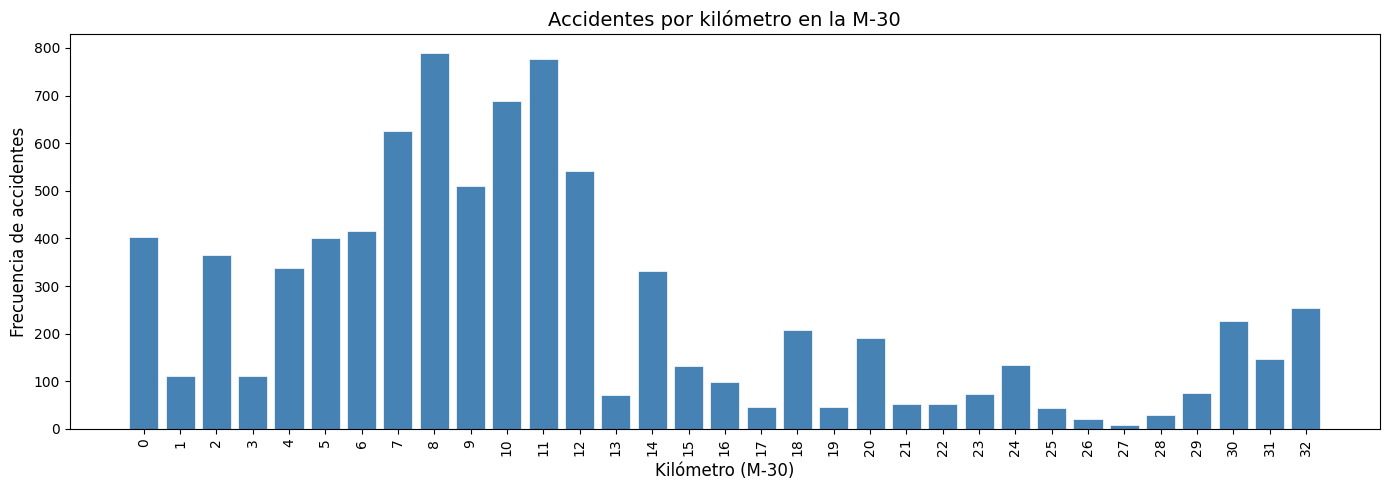

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Redondear KM a la unidad
m30_accidentes['KM_round'] = (
    m30_accidentes['KM']
    .dropna()
    .round(0)
    .astype(int)
)

# Contar frecuencia por KM
frecuencia = (
    m30_accidentes['KM_round']
    .dropna()
    .value_counts()
    .sort_index()
)

# ============================================================
# Gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    frecuencia.index,
    frecuencia.values,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel(
    'Kilómetro (M-30)',
    fontsize=12
)

ax.set_ylabel(
    'Frecuencia de accidentes',
    fontsize=12
)

ax.set_title(
    'Accidentes por kilómetro en la M-30',
    fontsize=14
)

ax.set_xticks(frecuencia.index)

ax.tick_params(
    axis='x',
    rotation=90
)

plt.tight_layout()


# ============================================================
# Guardar
# ============================================================

fig.savefig(
    f'{BASE_PATH}/accidentes_por_km.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

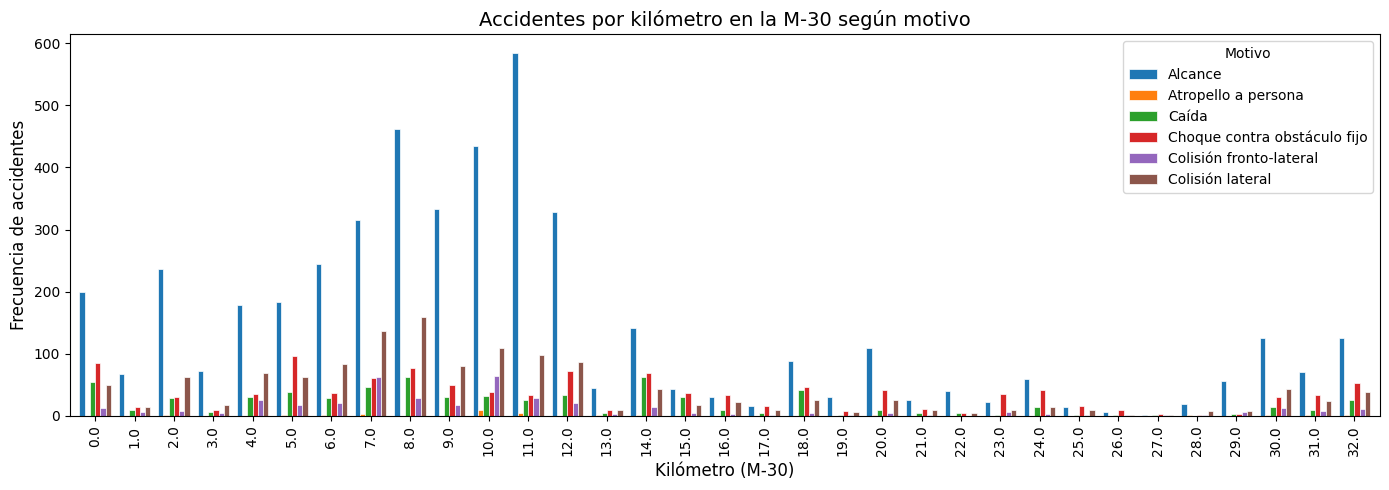

In [ ]:
# ============================================================
# Redondear KM
# ============================================================

m30_accidentes['KM_round'] = (
    m30_accidentes['KM']
    .dropna()
    .round(0)
    .astype(int)
)


# ============================================================
# Tabla pivote: filas = KM, columnas = tipo_accidente
# ============================================================

frecuencia = (
    m30_accidentes
    .dropna(subset=['KM_round', 'tipo_accidente'])
    .groupby(['KM_round', 'tipo_accidente'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)


# ============================================================
# Gráfico de barras agrupadas
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

frecuencia.plot(
    kind='bar',
    ax=ax,
    edgecolor='white',
    linewidth=0.5,
    width=0.8
)

ax.set_xlabel(
    'Kilómetro (M-30)',
    fontsize=12
)

ax.set_ylabel(
    'Frecuencia de accidentes',
    fontsize=12
)

ax.set_title(
    'Accidentes por kilómetro en la M-30 según motivo',
    fontsize=14
)

ax.legend(
    title='Motivo',
    fontsize=10
)

ax.tick_params(
    axis='x',
    rotation=90
)

# Escala logarítmica (opcional)
# ax.set_yscale('log')

plt.tight_layout()


# ============================================================
# Guardar
# ============================================================

fig.savefig(
    f'{BASE_PATH}/accidentes_por_km_motivo.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

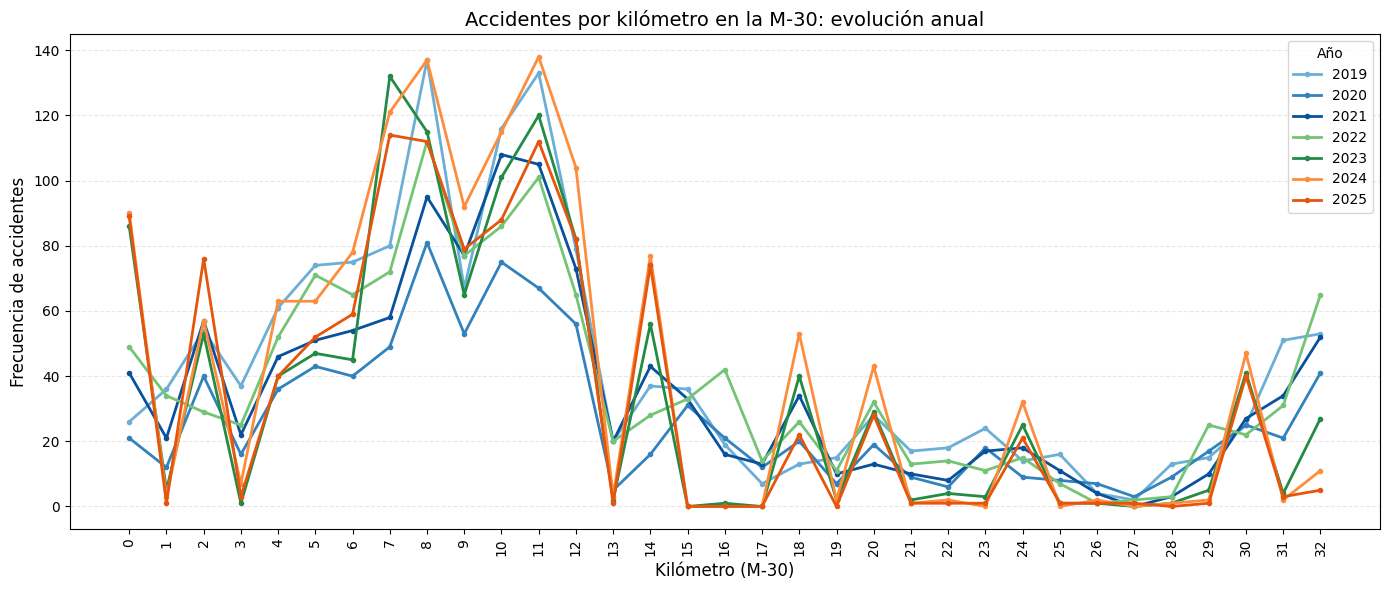

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# Comparativa de accidentes por KM entre años
# ============================================================

# Asegurar que fecha esté en formato datetime
# m30_accidentes['fecha'] = pd.to_datetime(
#     m30_accidentes['fecha'],
#     dayfirst=True
# )

# Extraer año
m30_accidentes['anio'] = m30_accidentes['fecha'].dt.year


# Todos los kilómetros disponibles
kms = sorted(
    m30_accidentes['KM_round']
    .dropna()
    .unique()
)


# Todos los años disponibles
anios = sorted(
    m30_accidentes['anio']
    .dropna()
    .unique()
)


# ------------------------------------------------------------
# Paleta temporal
# ------------------------------------------------------------

colores_anio = {
    2019: '#6BAED6',
    2020: '#3182BD',
    2021: '#08519C',

    2022: '#74C476',
    2023: '#238B45',

    2024: '#FD8D3C',
    2025: '#E6550D'
}


# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))


for anio in anios:

    df_año = m30_accidentes[
        m30_accidentes['anio'] == anio
    ]

    frecuencia_año = (
        df_año['KM_round']
        .value_counts()
        .reindex(kms, fill_value=0)
        .sort_index()
    )

    ax.plot(
        frecuencia_año.index,
        frecuencia_año.values,
        color=colores_anio[int(anio)],
        marker='o',
        markersize=3,
        linewidth=2,
        label=str(int(anio))
    )


# ------------------------------------------------------------
# Formato
# ------------------------------------------------------------

ax.set_xlabel(
    'Kilómetro (M-30)',
    fontsize=12
)

ax.set_ylabel(
    'Frecuencia de accidentes',
    fontsize=12
)

ax.set_title(
    'Accidentes por kilómetro en la M-30: evolución anual',
    fontsize=14
)

ax.set_xticks(kms)

ax.tick_params(
    axis='x',
    rotation=90
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    title='Año',
    ncol=1,
    fontsize=10
)

plt.tight_layout()


# ------------------------------------------------------------
# Guardar
# ------------------------------------------------------------

fig.savefig(
    f'{BASE_PATH}/comparativa_accidentes_por_km_anio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

## Frecuencias por Mes y Año

In [ ]:
m30_accidentes_mes = (
    m30_accidentes
    .groupby([
        m30_accidentes['fecha'].dt.year.rename('anio'),
        m30_accidentes['fecha'].dt.month.rename('mes')
    ])
    .size()
    .reset_index(name='Frecuencia')
)

m30_accidentes_mes.to_parquet(f'{BASE_PATH}/m30_accidentes_eventos_mes.parquet', index = True)

In [ ]:
m30_accidentes_mes = pd.read_parquet(f'{BASE_PATH}/m30_accidentes_eventos_mes.parquet')
print(m30_accidentes_mes)

    anio  mes  Frecuencia
0   2019    1         119
1   2019    2         125
2   2019    3         117
3   2019    4         112
4   2019    5         109
5   2019    6         100
6   2019    7         113
7   2019    8          50
8   2019    9         134
9   2019   10         165
10  2019   11         144
11  2019   12         127
12  2020    1         138
13  2020    2         129
14  2020    3          40
15  2020    4          13
16  2020    5          24
17  2020    6          50
18  2020    7          57
19  2020    8          39
20  2020    9          76
21  2020   10         106
22  2020   11         115
23  2020   12         121
24  2021    1          74
25  2021    2          78
26  2021    3         110
27  2021    4          86
28  2021    5          76
29  2021    6          92
30  2021    7          81
31  2021    8          47
32  2021    9         140
33  2021   10         152
34  2021   11         139
35  2021   12         127
36  2022    1          90
37  2022    

# Calles Urbanas

In [ ]:
urbanas_accidentes.head()

,num_expediente,fecha,hora,Lugar_Original,numero,cod_distrito,distrito,tipo_accidente,coordenada_x,coordenada_y,source_file,longitud,latitud,Motivo,Grupo_Calles
0,2018S017842,2019-02-04,1900-01-01 09:10:00,"CALL. ALBERTO AGUILERA, 1",1,1.0,CENTRO,Colisión lateral,440068.0,4475679.0,2019_Accidentalidad.csv,-3.706556,40.429591,Semáforo,Urbana
2,2019S000001,2019-01-01,1900-01-01 03:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11.0,CARABANCHEL,Alcance,439139.0,4470836.0,2019_Accidentalidad.csv,-3.717044,40.385895,Semáforo,Urbana
8,2019S000002,2019-01-01,1900-01-01 03:50:00,"CALL. CUART DE POBLET, 65",65,10.0,LATINA,Choque contra obstáculo fijo,436473.0,4472030.0,2019_Accidentalidad.csv,-3.748571,40.396452,Semáforo,Urbana
12,2019S000003,2019-01-01,1900-01-01 04:00:00,"CALL. MARCELO USERA, 30",30,12.0,USERA,Colisión fronto-lateral,440462.0,4470926.0,2019_Accidentalidad.csv,-3.701467,40.386802,Semáforo,Urbana
16,2019S000004,2019-01-01,1900-01-01 04:00:00,"CALL. ISLA DE OZA, 15",15,9.0,MONCLOA-ARAVACA,Choque contra obstáculo fijo,438274.0,4479629.0,2019_Accidentalidad.csv,-3.728088,40.465042,Semáforo,Urbana


In [ ]:
check_df(urbanas_accidentes)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 111506
Columns: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente            object
fecha             datetime64[ns]
hora              datetime64[ns]
Lugar_Original            object
numero                    object
cod_distrito              object
distrito                  object
tipo_accidente            object
coordenada_x             float64
coordenada_y             float64
source_file               object
longitud                 float64
latitud                  float64
Motivo                    object
Grupo_Calles              object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
num_expediente    0
fecha             0
hora              0
Lugar_Original    0
numero            0
cod_distrito      0
distrito          0
tipo_accidente    0
coordenada_x      0
coordenada_y 

## Frecuencias por calles originales

In [ ]:
# Crear el conteo y resetear el índice para convertirlo en DataFrame
tabla_frecuencia_urbanas = urbanas_accidentes['Lugar_Original'].value_counts().reset_index()

# Renombrar las columnas para que queden bonitas
tabla_frecuencia_urbanas.columns = ['Lugar', 'Frecuencia']

# Añadir una columna de Porcentaje (calculado manualmente o con normalize)
# Opción A: Calcular manual (más control sobre decimales)
total_datos = tabla_frecuencia_urbanas['Frecuencia'].sum()
tabla_frecuencia_urbanas['Porcentaje (%)'] = (tabla_frecuencia_urbanas['Frecuencia'] / total_datos) * 100

# Redondear a 2 decimales
tabla_frecuencia_urbanas['Porcentaje (%)'] = tabla_frecuencia_urbanas['Porcentaje (%)'].round(2)

# Guardar frecuencia_urbanas como parquet
tabla_frecuencia_urbanas.to_parquet(f'{BASE_PATH}/tabla_frecuencia_urbanas_accidentes.parquet', index=False)

In [ ]:
tabla_frecuencia_urbanas = pd.read_parquet(f'{BASE_PATH}/tabla_frecuencia_urbanas_accidentes.parquet')
print(f"Total de filas únicas encontradas: {len(tabla_frecuencia_urbanas)}")
print(f"Total de frecuencias: {sum(tabla_frecuencia_urbanas['Frecuencia'])}")
print("--- MOSTRANDO TABLA COMPLETA ---")
display(tabla_frecuencia_urbanas.head(150))

Total de filas únicas encontradas: 52048
Total de frecuencias: 111506
--- MOSTRANDO TABLA COMPLETA ---


,Lugar,Frecuencia,Porcentaje (%)
0,AVDA. ANDALUCIA / AUTOV. M-40,133,0.12
1,"AUTOV. A-2, +00500E",125,0.11
2,"AUTOV. A-42, +00500S",111,0.10
3,AVDA. ARCENTALES / AUTOV. M-40,99,0.09
4,"AUTOV. M-23, 0",97,0.09
5,PASEO. CASTELLANA / PLAZA. LIMA,95,0.09
6,AVDA. ALBUFERA / AUTOV. M-40,92,0.08
7,CALL. FUENTE CARRANTONA / AUTOV. M-23,90,0.08
8,"AUTOV. A-42, +00500E",88,0.08
9,AVDA. POBLADOS / AUTOV. A-42,78,0.07


In [ ]:
total_accidentes = len(urbanas_accidentes)
print(f"Total de accidentes: {total_accidentes:,}")

Total de accidentes: 111,506


## Frecuencias por Mes y Año

In [ ]:
urbanas_accidentes_mes = (
    urbanas_accidentes
    .groupby([
        urbanas_accidentes['fecha'].dt.year.rename('anio'),
        urbanas_accidentes['fecha'].dt.month.rename('mes')
    ])
    .size()
    .reset_index(name='Frecuencia')
)

urbanas_accidentes_mes.to_parquet(f'{BASE_PATH}/urbanas_accidentes_eventos_mes.parquet', index = True)

In [ ]:
urbanas_accidentes_mes = pd.read_parquet(f'{BASE_PATH}/urbanas_accidentes_eventos_mes.parquet')
print(urbanas_accidentes_mes.head)

<bound method NDFrame.head of     anio  mes  Frecuencia
0   2019    1        1439
1   2019    2        1410
2   2019    3        1580
3   2019    4        1513
4   2019    5        1583
5   2019    6        1594
6   2019    7        1519
7   2019    8        1005
8   2019    9        1459
9   2019   10        1784
10  2019   11        1678
11  2019   12        1568
12  2020    1        1412
13  2020    2        1430
14  2020    3         694
15  2020    4         222
16  2020    5         608
17  2020    6        1031
18  2020    7        1105
19  2020    8         766
20  2020    9        1068
21  2020   10        1154
22  2020   11        1214
23  2020   12        1261
24  2021    1         768
25  2021    2         937
26  2021    3        1219
27  2021    4        1166
28  2021    5        1352
29  2021    6        1443
30  2021    7        1208
31  2021    8         874
32  2021    9        1345
33  2021   10        1696
34  2021   11        1549
35  2021   12        1425
36  2022